# Credit Shield: Identifying and Mitigating Loan Default Risk

**Problem Statement**: Financial institutions face increasing loan defaults, leading to revenue loss and higher risk exposure. This project aims to analyze customer demographics, transaction behavior, and credit patterns to identify key factors driving loan defaults, segment high-risk customers, and recommend strategies to reduce default rates and improve risk management.

---


## Analysis Strategy: "Insight Over Volume"
This notebook explores the core drivers of credit default through univariate and bivariate analysis, focusing on behavioral patterns and financial capacity markers.

In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Set Plotting Aesthetics
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 6)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data/processed/cleaned_credit_data.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 30000 rows, 32 columns


## 1. Univariate Analysis: Understanding the Population
Establishing raw distributions for credit limits, ages, and default prevalence.

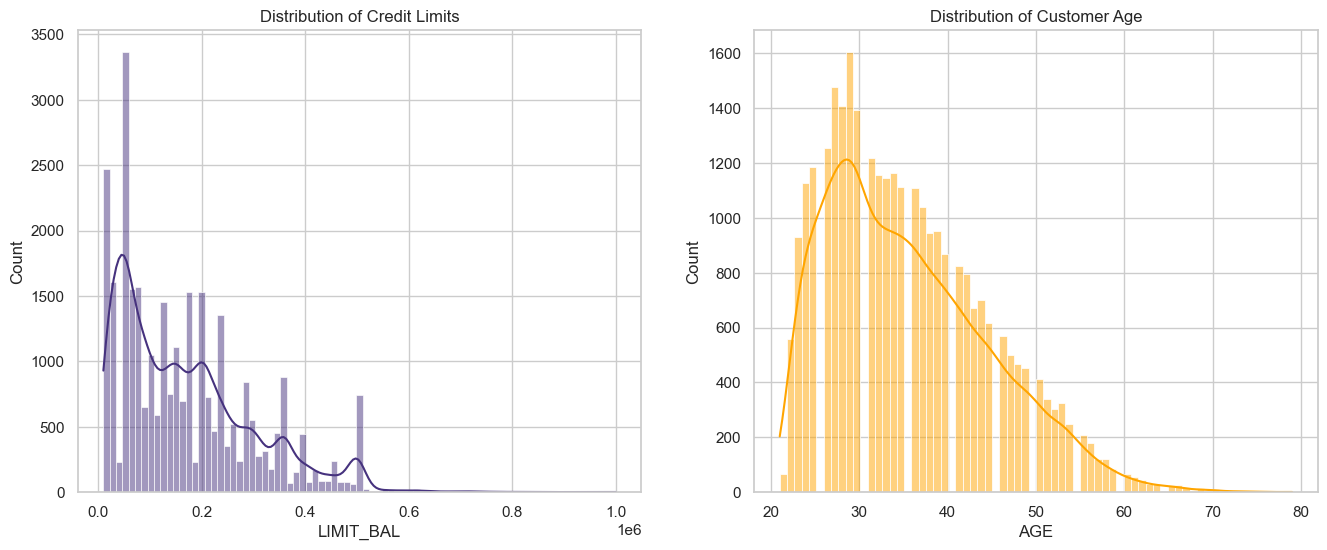

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Limit Balance Distribution
sns.histplot(df['LIMIT_BAL'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Credit Limits')

# Plot 2: Age Distribution
sns.histplot(df['AGE'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Customer Age')

plt.show()

> **Insight**: [Write your observation here. Is the credit limit skewed? What is the dominant age group in your portfolio?]

## 2. Bivariate Analysis: Investigating Risk Drivers
Examining how demographic factors correlate with default rates.

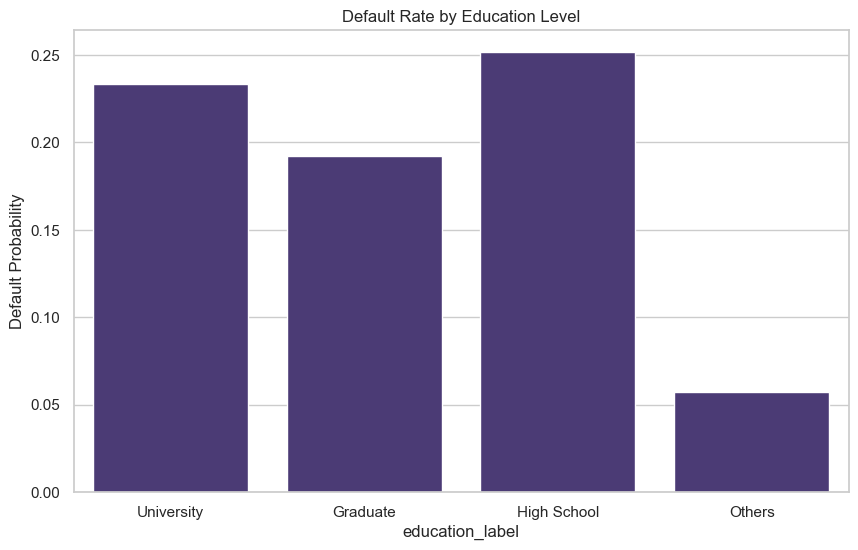

In [17]:
# Default Rate by Education
plt.figure(figsize=(10, 6))
sns.barplot(x='education_label', y='default_status', data=df, errorbar=None)
plt.title('Default Rate by Education Level')
plt.ylabel('Default Probability')
plt.show()

> **Insight**: [Which education segment carries the highest risk? Why might that be?]

/var/folders/hf/68m7jlj500vg4mg37y2mzttc0000gn/T/ipykernel_25685/3521809447.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='marriage_label', y='default_status', data=df, palette='viridis', errorbar=None)


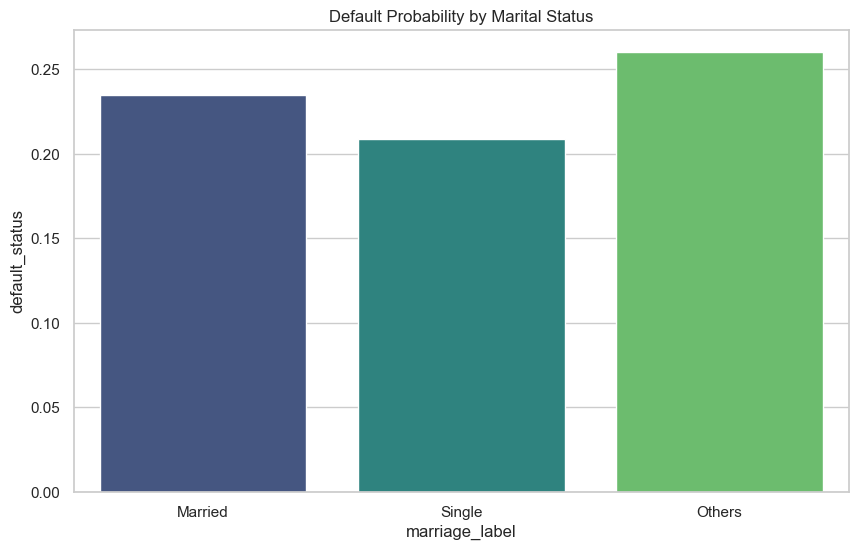

In [18]:
# Default Rate by Marital Status
plt.figure(figsize=(10, 6))
sns.barplot(x='marriage_label', y='default_status', data=df, palette='viridis', errorbar=None)
plt.title('Default Probability by Marital Status')
plt.show()

> **Insight**: [Analyze if married, single, or others show distinct default behaviors. Does 'Single' carry a higher risk profile?]

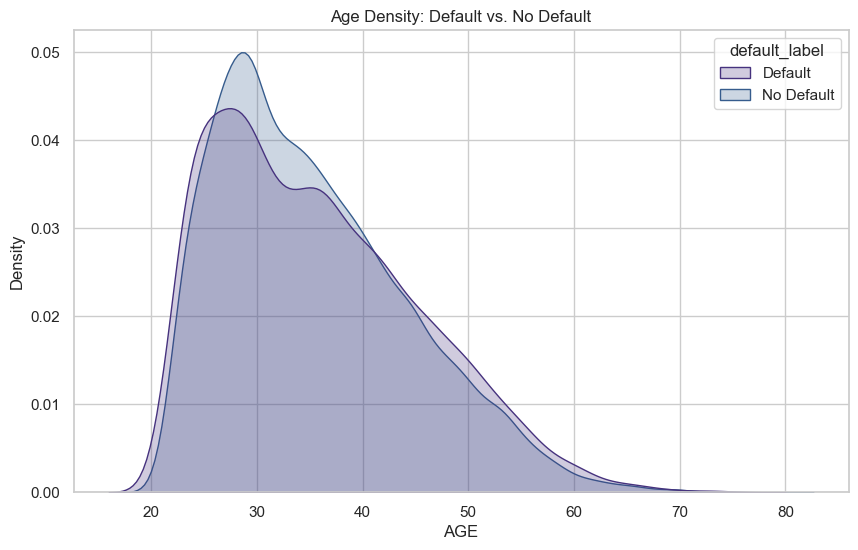

In [19]:
# Age vs Default
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='AGE', hue='default_label', fill=True, common_norm=False)
plt.title('Age Density: Default vs. No Default')
plt.show()

> **Insight**: [Is there a specific age bracket where the probability of default peaks?]

## 3. Behavioral Trends: 6-Month Payment History
Tracking how delays evolve over time to look for consistent warning signals.

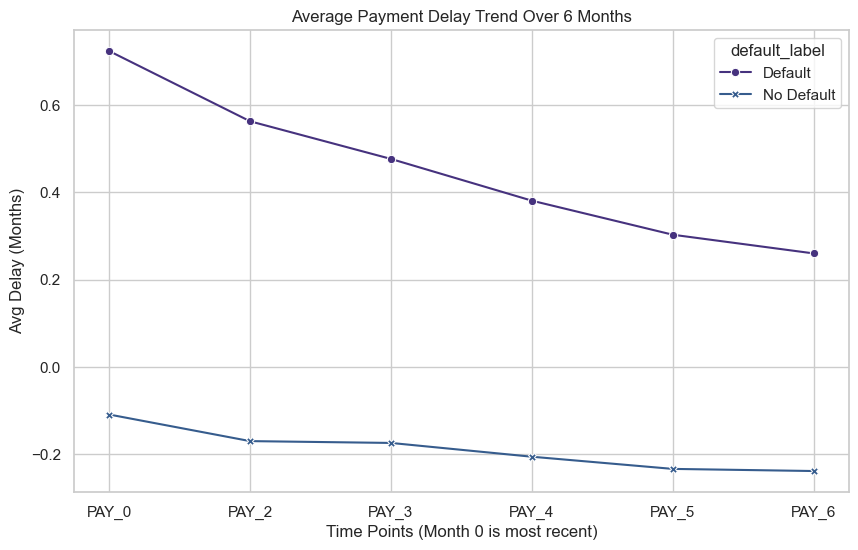

In [20]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df_trends = df.groupby('default_label')[pay_cols].mean().T

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_trends, markers=True, dashes=False)
plt.title('Average Payment Delay Trend Over 6 Months')
plt.ylabel('Avg Delay (Months)')
plt.xlabel('Time Points (Month 0 is most recent)')
plt.show()

> **Insight**: [Note how the delay values for defaulters remain consistently higher. Is the gap widening or narrowing over time?]

## 4. Financial & Engineering Validation
Testing the effectiveness of the engineered features (`utilization_ratio` and `risk_tier`).

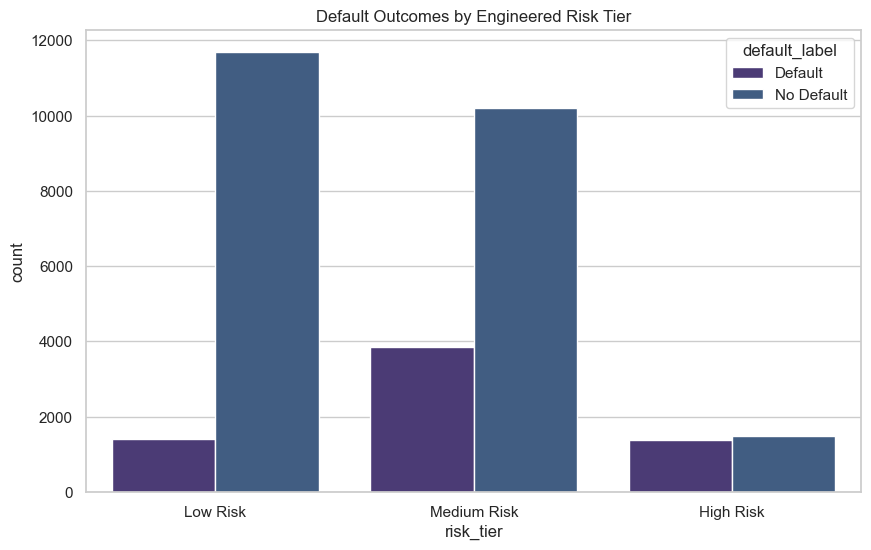

In [21]:
plt.figure(figsize=(10, 6))
order = ['Low Risk', 'Medium Risk', 'High Risk']
sns.countplot(x='risk_tier', hue='default_label', data=df, order=order)
plt.title('Default Outcomes by Engineered Risk Tier')
plt.show()

> **Insight**: [How effective is the 'High Risk' tier? Does it successfully concentrate the defaulters into one segment?]

### 4.1. Credit Allocation Deep-Dive
Visualizing how the bank currently segments credit limits across demographics.

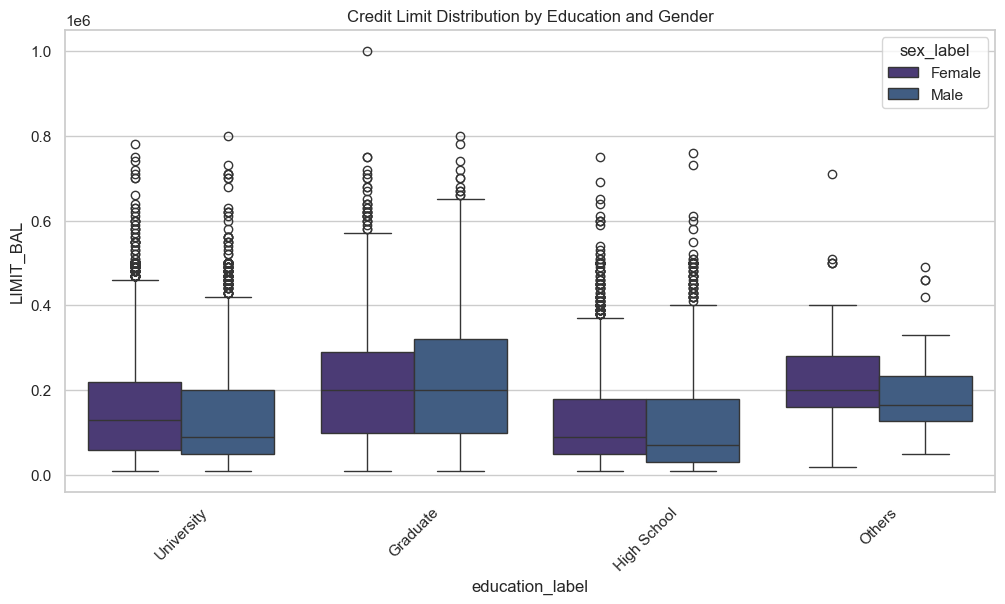

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='education_label', y='LIMIT_BAL', hue='sex_label', data=df)
plt.title('Credit Limit Distribution by Education and Gender')
plt.xticks(rotation=45)
plt.show()

> **Insight**: [Note if there is a 'Glass Ceiling' in limit allocation or if Graduate School students receive significantly higher starting limits.]

## 5. Multi-variate Correlation
Mapping the relationships between numerical features and the target.

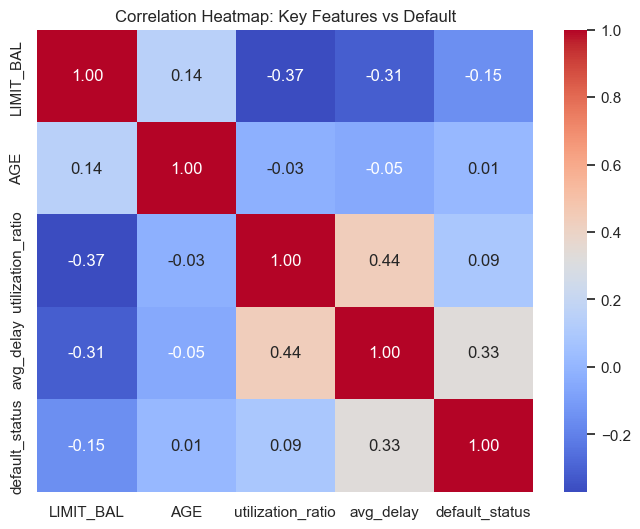

In [23]:
num_cols = ['LIMIT_BAL', 'AGE', 'utilization_ratio', 'avg_delay', 'default_status']
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Key Features vs Default')
plt.show()

### 5.1. Multivariate Clustering (Pairplot)
Looking for visual clumps of defaulters across the top 4 predictive variables.

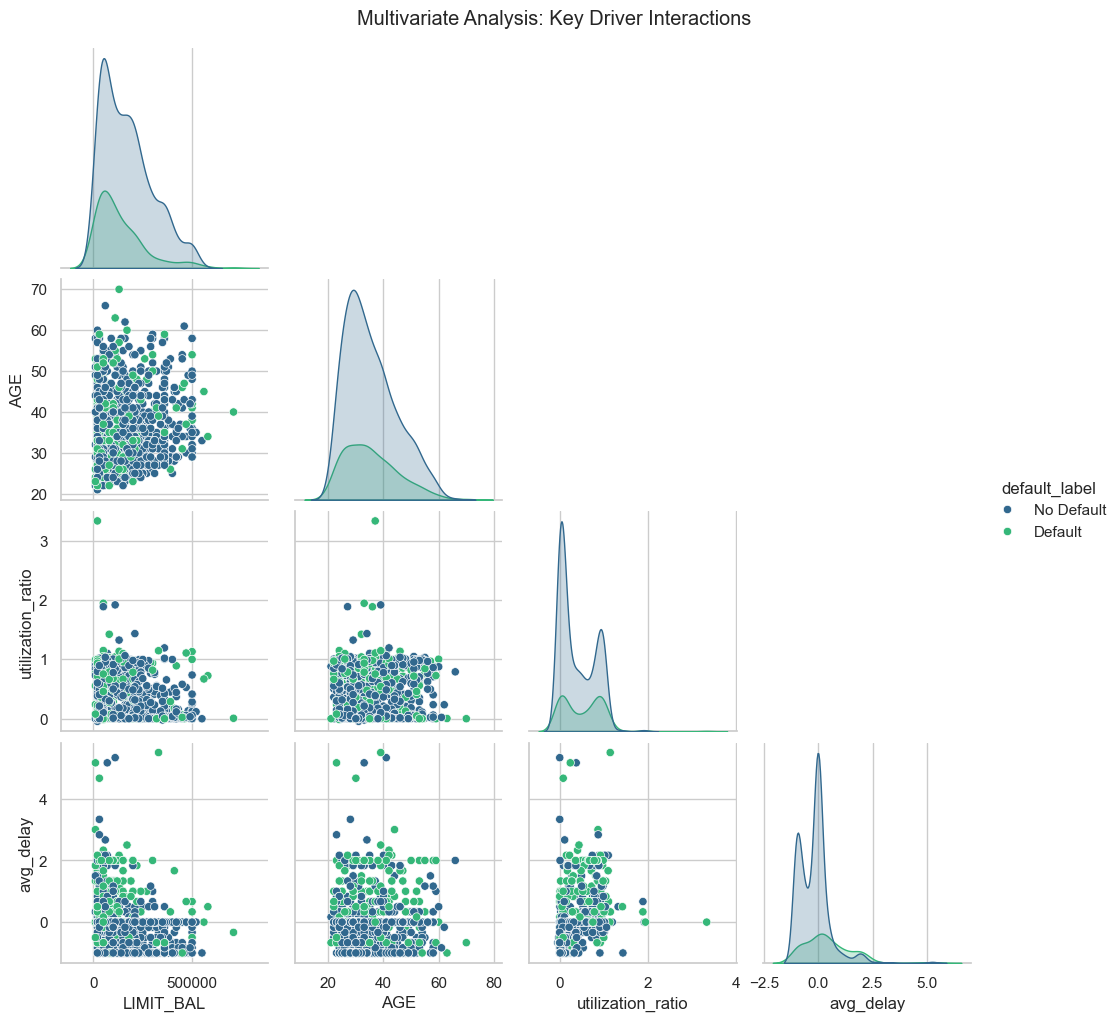

In [24]:
# Sample to keep it fast while retaining distribution characteristics
df_sample = df.sample(n=1000, random_state=42)
cols_to_plot = ['LIMIT_BAL', 'AGE', 'utilization_ratio', 'avg_delay', 'default_label']

sns.pairplot(df_sample[cols_to_plot], hue='default_label', corner=True, palette='viridis')
plt.suptitle('Multivariate Analysis: Key Driver Interactions', y=1.02)
plt.show()

> **Insight**: [Where do the 'Default' points (hue) concentrate? Do they cluster at high utilization and high average delay?]

## Final EDA Summary
1.  **Metric 1**: [Summarize findings]
2.  **Metric 2**: [Summarize findings]
3.  **Next Move**: These insights will now be formally tested in the `04_statistical_analysis.ipynb`.